## **Caracterização composicional de sequências de DNA** 

### Projeto final de Práticas em Ciências de Dados (PCD): 1º Semestre de 2026 | Ilum Escola de Ciência (CNPEM)
##### **Angelica Aracava Lopes (2610047) - Turma 2026**

---

Este projeto apresenta o desenvolvimento de um **analisador de sequências de DNA** implementado em Python, voltado à aplicação prática de conceitos fundamentais da linguagem na resolução de problemas reais.

**Objetivo:** Aplicação dos conceitos fundamentais da linguagem Python - strings, dicionários, funções, listas, gráficos - na resolução de problemas relacionados a análise de sequências genéticas, principalmente na área da Bioinformática.

**Como executar:** Execute as células na ordem apresentada. ***Atenção:*** as células da seção 9 requerem entrada interativa do usuário antes de gerar os resultados.  

---
> **Referências:**
> 
> ALBERTS, Bruce et al. Biologia molecular da célula. 6. ed. Porto Alegre: Artmed, 2017.
>
> HUNTER, John D. Matplotlib: a 2D graphics environment. Computing in Science & Engineering, v. 9, n. 3, p. 90–95, 2007. DOI: 10.1109/MCSE.2007.55.
>
> LESK, Arthur M. Introdução à bioinformática. 2. ed. Porto Alegre: Artmed, 2008. 384 p.
>
> 
> NATIONAL HUMAN GENOME RESEARCH INSTITUTE. Single nucleotide polymorphisms (SNPs). Bethesda: NHGRI, 2024.
>
> VAN ROSSUM, Guido; DRAKE, Fred L. Python 3 reference manual. Scotts Valley: CreateSpace, 2009. ISBN 9781441412690.
>
> WATSON, J. D.; CRICK, F. H. C. Molecular structure of nucleic acids: a structure for deoxyribose nucleic acid. Nature, Londres, v. 171, p. 737–738, abr. 1953. DOI: 10.1038/171737a0.
>
> 
> *Este projeto foi desenvolvido com o auxílio de IA generativa - Claude - para esclarecimento de dúvidas, ajustes no projeto e organização de fontes.

---
## 1. Importação de bibliotecas

Antes de iniciar qualquer análise é necessário **importar as bibliotecas** que serão utilizadas.

> **Bibliotecas Python:** coleção de códigos e funções prontas para uso, utilizadas na resolução de problemas comuns ou complexos.

- **`collections.Counter`** — nativa do Python; conta elementos de forma eficiente sem precisar de loops manuais.
- **`random`** — nativa do Python; usada para simular mutações aleatórias em bases nucleotídicas.
- **`matplotlib.pyplot`** — biblioteca externa para criação de gráficos científicos.

In [22]:

""" 
	Bibliotecas importadas:
	'Counter' conta elementos de iteráveis (listas) de forma otimizada;
	'random' fornece funções para geração de valores aleatórios;
	'matplotlib.pyplot' é a interface principal para criação de gráficos (o apeplido 'plt' é a convenção);
	'gridspec' permite organizar múltiplos gráficos em um painel. 
	
"""


from collections import Counter
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
## 2. Validação e limpeza dos dados

Com as bibliotecas importadas, devemos validar os dados inseridos.

Sequências de DNA só podem conter as bases **A**, **T**, **C** e **G**. Se uma sequência que será analisada tiver letras inválidas, espaços acidentais ou números, a função `validar_sequencia()` aponta o erro antes de dados incorretos serem processados.

Para realizar isso, temos os seguintes métodos (funções associadas a objetos):
- `isinstance()` : Verifica o tipo da variável antes de processar;
- `.upper()` / `.strip()` / `.replace()` : Limpeza de strings;
- `set()` : Conjunto para verificação eficiente de pertencimento;
- `raise ValueError` : Interrompe o programa com mensagem de erro clara.

In [2]:
def validar_sequencia(sequencia):

	"""
	    Valida e limpa uma sequência de DNA.

		    - Converte para maiúsculas
			- Remove espaços
		    - Verifica se contém apenas A, T, G, C

	    Parâmetros:
	        sequencia (str): string de DNA a ser validada.

	    Retorna:
	        str: sequência limpa e validada.

	    Lança:
		    TypeError  : se a entrada não for uma string.
	        ValueError : se estiver vazia ou com bases inválidas.
	 """
	
	if not isinstance (sequencia, str):
		raise TypeError(f'Esperado uma string, recebido: {type(sequencia)}')

	sequencia = sequencia.upper().strip().replace(" ", "")
	
	if len(sequencia) == 0:
		raise ValueError ("A sequência está vazia!")

	bases_validas = set("ATCG")
	for base in sequencia:
		if base not in bases_validas:
			raise ValueError(f'Base inválida encontrada: {base}. Use apenas A, T, C ou G.')
	
	return sequencia

---
## 3. Análises básicas

Com os dados validados é possível iniciar as análises efetivamente. Este bloco contém 4 funções que formam a base para as análises seguintes.

#### `contar_bases()` — composição nucleotídica
Retorna quantas vezes cada base (A, T, G, C) aparece na sequência.  
Usa `Counter`, que é eficiente do que um loop manual com `if`.

#### `calcular_gc()` — conteúdo de GC na sequência
O **Conteúdo de GC** mede a proporção de guaninas e citosinas na sequência.  
Pares G-C são unidos por **3 pontes de hidrogênio** (contra 2 nos pares A-T), tornando regiões ricas em GC termicamente mais estáveis.  
**Fórmula:** `GC% = (G + C) / total × 100`

#### `calcular_at()` — conteúdo de AT na sequência
Como AT + GC = 100% por definição, o conteúdo de AT é calculado diretamente como complemento de GC - reutilizando `calcular_gc()` sem recalcular a composição de bases.

#### `complementar_reverso()` — fita oposta
Na replicação do DNA, cada fita serve de molde para uma fita complementar lida no sentido oposto.  
Regras: A <--> T e G <--> C.  
Usa **list comprehension** e o slicing `[::-1]` para inversão.

In [3]:
def contar_bases(sequencia):

	"""
	
    Conta a ocorrência de cada base nucleotídica.

    Retorna:
        Dicionário com a quantidade de cada base na sequência = {'A': n, 'T': n, 'G': n, 'C': n}
		
    """
	
	sequencia = validar_sequencia(sequencia)
	contagem = Counter(sequencia)

	return {
		"A": contagem.get("A", 0),
		"T": contagem.get("T", 0),
		"C": contagem.get("C", 0),
		"G": contagem.get("G", 0)
	}

In [4]:
def calcular_gc(sequencia):

	"""
	
    Calcula o conteúdo de GC percentual na sequência.
    Fórmula: GC% = (G + C) / total × 100
	
    """

	sequencia = validar_sequencia(sequencia)
	bases = contar_bases(sequencia)

	total_gc = bases["G"] + bases["C"]
	porcentagem_gc = (total_gc / len(sequencia)) * 100

	return round(porcentagem_gc, 2)

In [5]:
def calcular_at(sequencia):
	
	"""
	
    Calcula o AT content percentual.
    Como AT + GC = 100%, basta subtrair o GC de 100.
	
    """
	
	return round(100 - calcular_gc(sequencia), 2)

In [6]:
def complementar_reverso(sequencia):

	"""
	
    Gera o complementar reverso de uma sequência de DNA.
    Regras: A <--> T, G <--> C. A fita resultante é lida no sentido inverso.
	
    """

	sequencia = validar_sequencia(sequencia)

	complemento = {
		"A": "T",
		"T": "A",
		"G": "C",
		"C": "G"
	}

	fita_complementar = [complemento[base] for base in sequencia]
	fita_reversa = fita_complementar[::-1]

	return "".join(fita_reversa)

## 4. Janela deslizante

Em vez de calcular um conteúdo único de GC (toda sequência), a **janela deslizante** percorre a sequência em trechos sobrepostos de tamanho fixo e calcula o GC de cada trecho.

Uma vez que o conteúdo de GC **varia regionalmente** ao longo do DNA, regiões com picos de GC tendem a ser mais estáveis, mais conservadas evolutivamente e, frequentemente correspondem a regiões codificantes ou regulatórias. Com isso, a função permite vizualizar a frequência dessas regiões na sequência analisada.

**Métodos utilizados:**
- `range(len(seq) - janela + 1)` — garante que a janela nunca ultrapasse o fim;
- `sequencia[i : i + janela]` — slicing para extrair cada trecho;
- `lista.append((i, gc))` — acumula tuplas na lista de resultados.

In [7]:
def gc_por_janela(sequencia, tamanho_janela):

	"""
    Calcula o conteúdo de GC em janelas deslizantes ao longo da sequência.

    Parâmetros:
        sequencia (str): sequência de DNA.
        tamanho_janela (int): número de bases por janela. Padrão: 10.

    Retorna:
        list[tupla]: lista de tuplas (posição_inicial, gc_content).
    """

	sequencia = validar_sequencia(sequencia)

	if tamanho_janela <= 0:
		raise ValueError("O tamanho da janela deve ser maior que zero.")
	if tamanho_janela > len(sequencia):
		raise ValueError(f'Janela ({tamanho_janela}) maior que a sequência ({len(sequencia)})')

	resultados = []

	for i in range(len(sequencia) - tamanho_janela + 1):
		janela = sequencia[i : i + tamanho_janela]
		gc = calcular_gc(janela)
		resultados.append((i, gc))

	return resultados

# 5. Busca de motifs

**Motifs** são sequências curtas de bases com significado biológico específico, sendo que localizar onde eles aparecem é uma das análises mais fundamentais em bioinformática.

##### Exemplos de motifs biológicos relevantes:
| Motif | Significado |
|-------|-------------|
| `ATG` | Códon de início — marca onde a tradução proteica começa |
| `TAA`, `TAG`, `TGA` | Códons de parada — marcam onde a tradução termina |
| `TATA` | Caixa TATA — região promotora que ativa a transcrição |

##### **Algoritmo:**
A função `buscar_motif()` percorre a sequência com um loop, extrai trechos do mesmo tamanho do motif buscado, e compara os dois. Quando há correspondência, a posição inicial é registrada.

> Este é um algoritmo de busca por força bruta. Para sequências genômicas muito longas, existem algoritmos mais eficientes como Boyer-Moore e KMP.

In [8]:
def buscar_motif(sequencia, motif):

	"""
    Localiza todas as ocorrências de um motif na sequência.

    Parâmetros:
        sequencia (str): sequência onde buscar.
        motif (str): padrão de bases a localizar.

    Retorna:
        list[int]: posições iniciais de cada ocorrência encontrada.
                   Lista vazia se o motif não for encontrado.
    """

	sequencia = validar_sequencia(sequencia)
	motif = validar_sequencia(motif)

	posicoes = []

	for i in range(len(sequencia) - len(motif) + 1):
		trecho = sequencia[i: i + len(motif)]
		if trecho == motif:
			posicoes.append(i)

	return posicoes

# 6. Simulação de mutações

Uma **mutação pontual**, chamada de **SNP** (*Single Nucleotide Polymorphism*), é a forma mais comum de variação genética entre indivíduos da mesma espécie.

A função `simular_mutacao()` reproduz de forma simplificada estas mutações. Para cada base da sequência, o programa gera um número aleatório entre 0 e 1: se esse número for menor que a taxa de mutação definida, a base é trocada por outra escolhida aleatoriamente (sempre diferente da original).

Para a aplicação, utilizamos os métodos:
| Método | Uso |
|----------|-----|
| `list(string)` | Converte string em lista (strings são imutáveis) |
| `random.random()` | Gera número entre 0.0 e 1.0 |
| `random.choice()` | Sorteia elemento de uma lista |
| `random.seed()` | Fixa a semente para resultados reprodutíveis |
| `enumerate()` | Percorre com índice e valor ao mesmo tempo |

In [9]:
def simular_mutacao(sequencia, taxa_mutacao, semente=None):

	"""
    Simula mutações pontuais aleatórias em uma sequência de DNA.

    Parâmetros:
        sequencia (str)  : sequência original;
        taxa_mutacao (float): probabilidade de mutação por base (0 a 1);
        semente (int)  : semente para reprodutibilidade. None = aleatório.

    Retorna:
        tupla: (sequencia_mutada, lista_de_mutacoes)
    """

	sequencia = validar_sequencia(sequencia)

	if not 0 <= taxa_mutacao <= 1:
		raise ValueError("A taxa de mutação deve estar entre 0 e 1.")

	if semente is not None:
		random.seed(semente)

	bases_todas = ["A", "T", "C", "G"]
	sequencia_lista = list(sequencia)

	mutacoes = []

	for i, base_original in enumerate(sequencia_lista):
		if random.random() < taxa_mutacao:
			opcoes = [b for b in bases_todas if b != base_original]
			base_nova = random.choice(opcoes)
			sequencia_lista[i] = base_nova
			mutacoes.append({
				"posicao": i,
				"original": base_original,
				"mutada": base_nova
			})

	sequencia_mutada = "".join(sequencia_lista)
	return sequencia_mutada, mutacoes

---
# 7. Relatório em texto

A função `imprimir_relatorio()` reune as informações coletadas de todas as funções anteriores e formata os resultados no terminal do usuário.

Para desempenhar esta tarefa, a função utiliza:
- **f-strings com formatação**: `f"{valor:3d}"` (reserva 3 espaços para o número, alinhando os valores em colunas), entre outras formatações utilizadas;
- **Multiplicação de string**: `"\uxxxx" * 14` gera uma barra visual proporcional à porcentagem;
- **Dicionário de motifs**: associa cada padrão a sua descrição biológica, facilitando iteração.

In [19]:
def imprimir_relatorio(sequencia, nome_individuo = "Não informado.", motifs_extras=None):

	"""
    Exibe no terminal um relatório completo da análise da sequência.

    Parâmetros:
        sequencia (str): sequência de DNA a ser analisada.
    """

	sequencia = validar_sequencia(sequencia)
	linhas = []

	#Cabeçalho:
	linhas.append("\n" + "--" * 50)
	linhas.append("Análise de Bases em Sequências de DNA para aplicações em Bioinformática - Relatório de Análise ")
	linhas.append("--" * 50)

	#Informações gerais:
	linhas.append(f"\n{'Indivíduo':.<30} {nome_individuo}")
	linhas.append(f"{'Sequência original':.<30} {sequencia}")
	linhas.append(f"{'Comprimento':.<30} {len(sequencia)} bases")
	linhas.append(f"{'Complementar reverso':.<30} {complementar_reverso(sequencia)}")

	#Composição de bases:
	linhas.append("\n--- Composição de Bases " + "--" * 35 + "\n")
	bases = contar_bases(sequencia)
	simbolo = {"A": "\u2593", "T": "\u2591", "G": "\u2588", "C": "\u2592"}

	for base, qtd in bases.items():
		porcentagem = round(qtd / len(sequencia) * 100, 1)
		barra = simbolo[base] * int(porcentagem / 2)
		linhas.append(f"{base} ={qtd:3d}({porcentagem:5.1f}% ) {barra}")

	# AT e GC na sequência:
	gc = calcular_gc(sequencia)
	at = calcular_at(sequencia)
	linhas.append("\n--- Conteúdo de AT e GC na sequência " + "--" * 29)
	linhas.append(f"\nConteúdo de GC: {gc}%")
	linhas.append(f"Conteúdo de AT: {at}%")

	if gc < 40:
		perfil = "baixo - região rica em AT, menos estável termicamente"
	elif gc <= 60:
		perfil = "moderado - dentro da faixa típica de genomas eucarióticos"
	else:
		perfil = "alto - região rica em GC, mais estável termicamente"

	linhas.append(f"\nPerfil: {perfil}")

	#Busca de motifs padrão:
	linhas.append("\n--- Busca de Motifs " + "--" * 38 + "\n")
	motifs_padrao = {
		"ATG": "códon de início (Met)",
		"TAA": "códon de parada",
		"TAG": "códon de parada",
		"TGA": "códon de parada",
		"TATA": "caixa TATA (promotor)"
	}

	for motif, descricao in motifs_padrao.items():
		posicoes = buscar_motif(sequencia, motif)
		if posicoes:
			pos_str = ", ".join(str(p) for p in posicoes)
			linhas.append(f"{motif:6s}= ({descricao}): posições [{pos_str}]")
		else:
			linhas.append(f"{motif:6s}= ({descricao}): não encontrado.")

	#Busca de motifs extras informados pelo usuário:
	if motifs_extras:
		linhas.append("\n--- Motifs Personalizados" + "--" * 34 +"\n")
		for motif in motifs_extras:
			posicoes = buscar_motif(sequencia, motif)
			if posicoes:
				pos_str = ", ".join(str(p) for p in posicoes)
				linhas.append(f"{motif:6s}= (motif personalizado): posições [{pos_str}]")
			else:
				linhas.append(f"{motif:6s}= (motif personalizado): não encontrado.")

	relatorio = "\n".join(linhas)

	return relatorio

# 8. Salvando os dados e vizualização gráfica com Matplotlib

Por fim, `gerar_graficos()` e `salvar_relatorio()` encerram a análise: geram e salvam o relatório final da análise, contendo todas as informações processadas, e três gráficos complementares:


| Gráfico | Tipo | O que mostra |
|---------|------|-------------|
| Composição de bases | Barras | Quantidade de A, T, G e C |
| GC vs AT | Pizza | Proporção entre os dois grupos |
| GC por janela | Linha | Como o conteúdo de GC varia ao longo da sequência |


Para a plotagem dos gráficos, a função `gerar_graficos()` utiliza:

- **`GridSpec`** — divide o painel em uma grade e permite que gráficos ocupem múltiplas colunas;
- **`fig.suptitle()`** — título centralizado para o painel inteiro;
- **`ax.axhline()`** — linha horizontal de referência (GC global);
- **`fill_between()`** — preenche a área sob a curva, tornando o gráfico mais legível.

In [11]:
def gerar_graficos(sequencia, tamanho_janela, nome_individuo = "Não informado", nome_arquivo = "analise_dna.png"):
	
	"""
    Gera um painel com 3 gráficos da análise da sequência de DNA.

    Gráfico 1 (superior esquerdo): composição de bases (barras)
    Gráfico 2 (superior direito): conteúdo de GC vs AT (pizza)
    Gráfico 3 (inferior, largo): conteúdo de GC por janela deslizante (linha)

    Parâmetros:
        sequencia (str): sequência de DNA.
        tamanho_janela (int): tamanho da janela deslizante. Padrão: 10.
    """
	
	sequencia = validar_sequencia(sequencia)

	bases = contar_bases(sequencia)
	gc = calcular_gc(sequencia)
	at = calcular_at(sequencia)
	janelas = gc_por_janela(sequencia, tamanho_janela)

	posicoes_janela, valores_gc = zip(*janelas)

	fig = plt.figure(figsize=(15, 10))
	fig.patch.set_facecolor("#fafbfc")

	gs = gridspec.GridSpec(2, 2, figure = fig, hspace = 0.45, wspace = 0.35, top = 0.88, bottom = 0.1)
	fig.suptitle(f"Relatório Gráfico: Análise de DNA - {nome_individuo}", 
				 fontsize = 16, 
				 fontweight = "bold", 
				 color = "#1a1d27", 
				 y = 0.96)

	cores_bases = {"A": "#4A90D9", "T": "#E05252", "G": "#5CB85C", "C": "#D4A84B"}

	hatch_bases = {"A": "/", "T": "\\", "G": "x", "C": "."}
	hatch_pizza = ["+", "-"]

	#Gráfico 1: Barras
	ax1 = fig.add_subplot(gs[0, 0])
	ax1.set_facecolor("#fafbfc")

	nomes = list(bases.keys())
	valores = list(bases.values())
	cores = [cores_bases[b] for b in nomes]
	hatches = [hatch_bases[b] for b in nomes]

	barras = ax1.bar(nomes, valores, color = cores, width = 0.5, hatch = hatches, edgecolor = "black", zorder = 3)
	for barra, val in zip(barras, valores):
		ax1.text(barra.get_x() + barra.get_width() / 2, 
				 barra.get_height() + 0.3, 
				 str(val), 
				 ha="center", 
				 va = "bottom", 
				 color = "#2b2b2b", 
				 fontsize = 11, 
				 fontweight = "bold")
		
	ax1.set_title("Composição de Bases", color="#1a1d27", fontsize=13, pad=12)
	ax1.set_xlabel("Base do nucleotídeo", color="#555555", fontsize=10)
	ax1.set_ylabel("Contagem", color="#555555", fontsize=10)
	ax1.tick_params(colors="#555555")
	ax1.grid(axis="y", color="#dddddd", zorder=0)
	for spine in ax1.spines.values():
		spine.set_edgecolor("#cccccc")

	#Gráfico 2: Pizza
	ax2 = fig.add_subplot(gs[0, 1]) 
	ax2.set_facecolor("#fafbfc")
	
	fatias, textos, autopcts = ax2.pie([gc, at], 
									   labels = ["Conteúdo de GC", "Conteúdo de AT"], 
									   colors = ["#5CB85C", "#4A90D9"], 
									   autopct = "%1.1f%%", 
									   startangle = 90, 
									   explode = (0.05, 0), 
									   textprops = {"color": "#2b2b2b", "fontsize": 10})

	for fatia, h in zip(fatias, hatch_pizza):
		fatia.set_hatch(h)
		fatia.set_edgecolor("black")
		
	for fatia in fatias:
		fatia.set_edgecolor("black")
		
	for ap in autopcts:
		ap.set_color("#ffffff")
		ap.set_fontweight("bold")
		
	ax2.set_title("Conteúdo de GC vs AT", color="#1a1d27", fontsize=13, pad=12)
	
	#Gráfico 3: Linha
	ax3 = fig.add_subplot(gs[1, :]) 
	ax3.set_facecolor("#fafbfc")
	
	ax3.plot(posicoes_janela, 
			 valores_gc, 
			 color = "#1a7a1a", 
			 linewidth = 2.5, 
			 zorder = 3, 
			 label = "GC por janela")
	area = ax3.fill_between(posicoes_janela,
					 valores_gc,
					 alpha=0.25,
					 color="#2ecc71",
					 zorder = 2)
	
	area.set_hatch("//")
	area.set_edgecolor("#1a7a1a")
	
	ax3.axhline(y=gc, 
				color="#c0392b", 
				linestyle="--", 
				linewidth=2, 
				label = f"GC global: {gc}%", zorder = 2)
	
	ax3.set_title(f"Conteúdo de GC por Janela Deslizante (janela = {tamanho_janela} bases)", 
				  color = "#1a1d27", fontsize = 13, pad = 12)
	ax3.set_xlabel("Posição na sequência (base)", color = "#555555", fontsize = 10)
	ax3.set_ylabel("GC content (%)", color = "#555555", fontsize = 10)
	ax3.set_ylim(0, 105)
	ax3.tick_params(colors="#555555")
	ax3.grid(color="#dddddd", zorder=0)
	ax3.legend(facecolor="#ffffff", labelcolor="#2b2b2b", fontsize=10)
	for spine in ax3.spines.values():
		spine.set_edgecolor("#cccccc")
		
	plt.savefig(nome_arquivo, dpi=150, bbox_inches="tight", facecolor = fig.get_facecolor())
	print(f"Gráfico salvo como '{nome_arquivo}'")
	plt.show()
	
	return fig, nome_arquivo

In [12]:
def salvar_relatorio(sequencia, seq_mutada, mutacoes, taxa_mutacao, motifs_extras, nome_individuo = "Não informado", nome_arquivo = "relatorio_dna.txt"):
	
	"""
	Gera e salva em arquivo .txt um relatório completo da análise de uma sequência de DNA.
	
	O relatório inclui:
		- Cabeçalho com identificação do indivíduo e sequência analisada;
		- Relatório principal de composição de bases (via `imprimir_relatorio`);
		- Simulação de mutação com lista de alterações e comparação do conteúdo GC;
		- Busca pelo códon de início 'ATG' na sequência original;
		- Busca por motifs personalizados adicionais, se fornecidos.
		
	Parâmetros:
		sequencia (str): Sequência de DNA original (será validada internamente).
		seq_mutada (str): Sequência de DNA após simulação de mutação.
		mutacoes (list[dict]): Lista de mutações aplicadas. Cada elemento é um dicionário 
			com as chaves 'posicao' (int), 'original' (str) e 'mutada' (str).
		taxa_mutacao (float): Taxa de mutação utilizada na simulação, entre 0 e 1 (ex: 0.05 representa 5%).
		motifs_extras (list[str] | None): Lista de motifs adicionais a serem buscados
			na sequência original. Pode ser None ou lista vazia para omitir essa seção.
		nome_individuo (str, opcional): Nome do indivíduo associado à sequência --> Padrão: "Não informado".
		nome_arquivo (str, opcional): Caminho e nome do arquivo de saída --> Padrão: "relatorio_dna.txt".
		
	Retorna:
		str: O nome/caminho do arquivo gerado.
		
	"""
	sequencia = validar_sequencia(sequencia)
	gc_original = calcular_gc(sequencia)
	gc_mutada = calcular_gc(seq_mutada)
	motif_fixo = "ATG"
	posicoes = buscar_motif(sequencia, motif_fixo)
	
	linhas = []
	
	# Cabeçalho
	linhas.append("=" * 100)
	linhas.append("Análise de Bases em Sequências de DNA para aplicações em Bioinformática - Relatório Final")
	linhas.append("=" * 100)
	linhas.append(f"\nIndivíduo: {nome_individuo}")
	linhas.append(f"Sequência analisada ({len(sequencia)} bases):\n")
	linhas.append(f"{sequencia}\n")
	
	# Relatório principal
	linhas.append(imprimir_relatorio(sequencia, nome_individuo=nome_individuo, motifs_extras=motifs_extras))
	
	# Simulação de mutação
	linhas.append(f"--- Simulação de Mutação (taxa: {taxa_mutacao * 100:.1f}%) " + "--" * 21 + "\n")
	linhas.append(f"Original : {sequencia}")
	linhas.append(f"Mutada   : {seq_mutada}")
	linhas.append(f"\nTotal de mutações: {len(mutacoes)}")
	
	for m in mutacoes:
		linhas.append(f"Posição {m['posicao']:3d}: {m['original']} --> {m['mutada']}")
		
	linhas.append(f"\nGC original: {gc_original}%")
	linhas.append(f"GC mutada: {gc_mutada}%")
	linhas.append(f"Variação: {round(gc_mutada - gc_original, 2):+.2f}%\n")
	
	# Busca de motif
	linhas.append(f"--- Busca de '{motif_fixo}' (códon de início) " + "--" * 30 + "\n")
	linhas.append(f"  Encontrado {len(posicoes)} vez(es): posições {posicoes}\n")

	# Busca de motifs extras
	if motifs_extras:
		linhas.append("\n--- Busca de Motifs Personalizados" + "--" * 30 + "\n")
		for motif in motifs_extras:
			posicoes = buscar_motif(sequencia, motif)
			linhas.append(f" '{motif}': encontrado {len(posicoes)} vez(es) --> posições {posicoes}")
		linhas.append("")
	
	# Rodapé
	linhas.append("=" * 100)
	linhas.append("Arquivo gerado automaticamente.")
	linhas.append("=" * 100)
	
	conteudo = "\n".join(linhas)
	
	with open(nome_arquivo, "w", encoding="utf-8") as f:
		f.write(conteudo)
		
	print(f"Relatório salvo como '{nome_arquivo}'")
	return nome_arquivo

# 9. Configurações do Usuário e execução completa

Estas células reúnem tudo o que foi definido ao longo do código e executa o programa com as respostas fornecidas personalizadas pelo usuário.
Após a execução, o relatório final personalizado é salvo em um arquivo `.txt` e o gráfico em `.png`.

> Campos deixados em branco assumem os valores padrão indicados entre colchetes.

**O que será executado:**

1. **Relatório em texto** — composição, conteúdo de GC, motifs biológicos etc.
2. **Simulação de mutação** — 10% de taxa (padrão), com comparação antes/depois
3. **Busca personalizada de motif** — localização de todos os códons requisitados pelo usuário
4. **Painel de gráficos** — visualização completa da análise

> **Observação:** A célula de gráficos exige que o Matplotlib esteja instalado. Caso não esteja: `pip install matplotlib`

In [17]:
# Configurações do Usuário

# 1. Nome do indivíduo:
NOME_INDIVIDUO = input("Nome do indivíduo da sequência: ").strip() or "Não informado."

# 2. Sequência ou geração aleatória:
print("Opção de sequência:\n")
print("  [1] Digitar manualmente.")
print("  [2] Gerar aleatoriamente.\n")
opcao_seq = input("Escolha (1 ou 2): ").strip()

if opcao_seq == "1":
	SEQUENCIA = input("Cole a sequência de DNA: ").strip().upper()
else:
	n_bases = input("Número de bases a gerar [padrão: 70]: ").strip()
	n_bases = int(n_bases) if n_bases.isdigit() else 70
	SEQUENCIA = "".join(random.choices("ATCG", k = n_bases))
	print(f"Sequência gerada ({n_bases} bases): {SEQUENCIA}")

# 3. Motifs extras (além dos padrão do relatório)
print("Motifs extras para buscar (separe por vírgula, ex: ATG,GCC).")
entrada_motifs = input("Motifs [Enter para pular]: ").strip().upper()
MOTIFS_EXTRAS = [m.strip() for m in entrada_motifs.split(",") if m.strip()] if entrada_motifs else []

# 4. Taxa de mutação
taxa_input = input("Taxa de mutação a simular, entre 0 e 1 [padrão: 0.10]: ").strip()
try:
    TAXA_MUTACAO = float(taxa_input)
    if not 0 <= TAXA_MUTACAO <= 1:
        raise ValueError
except (ValueError, TypeError):
    print("Valor inválido. Usando padrão: 0.10")
    TAXA_MUTACAO = 0.10

# 5. Salvar arquivos?
SALVAR = input("Salvar relatório e gráfico em arquivos? (s/n): ").strip().lower() == "s"

if SALVAR:
    # 6. Pasta de destino
    PASTA = input("Nome da pasta para salvar os arquivos [padrão: resultados_dna]: ").strip() or "resultados_dna"
    os.makedirs(PASTA, exist_ok=True)
    print(f"Pasta '{PASTA}' pronta.")

    # 7. Nome base dos arquivos
    NOME_BASE = input("Nome base dos arquivos, sem extensão [padrão: relatorio_dna]: ").strip() or "relatorio_dna"
    NOME_RELATORIO = os.path.join(PASTA, NOME_BASE + ".txt")
    NOME_GRAFICO = os.path.join(PASTA, NOME_BASE + ".png")
else:
    PASTA = None
    NOME_RELATORIO = "relatorio_dna.txt"
    NOME_GRAFICO = "analise_dna.png"

# Resumo das configurações
salvar_str = ("Sim — pasta: " + str(PASTA) + "/" + NOME_BASE) if SALVAR else "Não"
seq_preview = SEQUENCIA[:40] + ("..." if len(SEQUENCIA) > 40 else "")
print("\n" + "=" * 60)
print("Configurações registradas:")
print(f"  Indivíduo: {NOME_INDIVIDUO}")
print(f"  Sequência: {seq_preview}  ({len(SEQUENCIA)} bases)")
print(f"  Motifs extras: {MOTIFS_EXTRAS if MOTIFS_EXTRAS else 'nenhum'}")
print(f"  Taxa mutação: {TAXA_MUTACAO}")
print(f"  Salvar: {salvar_str}")
print("=" * 60)
print("Pronto! Execute a próxima célula para gerar o relatório completo.")

Nome do indivíduo da sequência:  TESTE


Opção de sequência:

  [1] Digitar manualmente.
  [2] Gerar aleatoriamente.



Escolha (1 ou 2):  2
Número de bases a gerar [padrão: 70]:  25


Sequência gerada (25 bases): GTGTCTATCTGTATTATCCGCTAAA
Motifs extras para buscar (separe por vírgula, ex: ATG,GCC).


Motifs [Enter para pular]:  ATG
Taxa de mutação a simular, entre 0 e 1 [padrão: 0.10]:  


Valor inválido. Usando padrão: 0.10


Salvar relatório e gráfico em arquivos? (s/n):  N



Configurações registradas:
  Indivíduo: TESTE
  Sequência: GTGTCTATCTGTATTATCCGCTAAA  (25 bases)
  Motifs extras: ['ATG']
  Taxa mutação: 0.1
  Salvar: Não
Pronto! Execute a próxima célula para gerar o relatório completo.



----------------------------------------------------------------------------------------------------
Análise de Bases em Sequências de DNA com Python para aplicações em Bioinformática - Relatório Final de Análise 
----------------------------------------------------------------------------------------------------

Indivíduo: TESTE
Sequência analisada (25 bases):

  GTGTCTATCTGTATTATCCGCTAAA


----------------------------------------------------------------------------------------------------
Análise de Bases em Sequências de DNA para aplicações em Bioinformática - Relatório de Análise 
----------------------------------------------------------------------------------------------------

Indivíduo..................... TESTE
Sequência original............ GTGTCTATCTGTATTATCCGCTAAA
Comprimento................... 25 bases
Complementar reverso.......... TTTAGCGGATAATACAGATAGACAC

--- Composição de Bases ----------------------------------------------------------------------

A =  6( 24.0% ) 

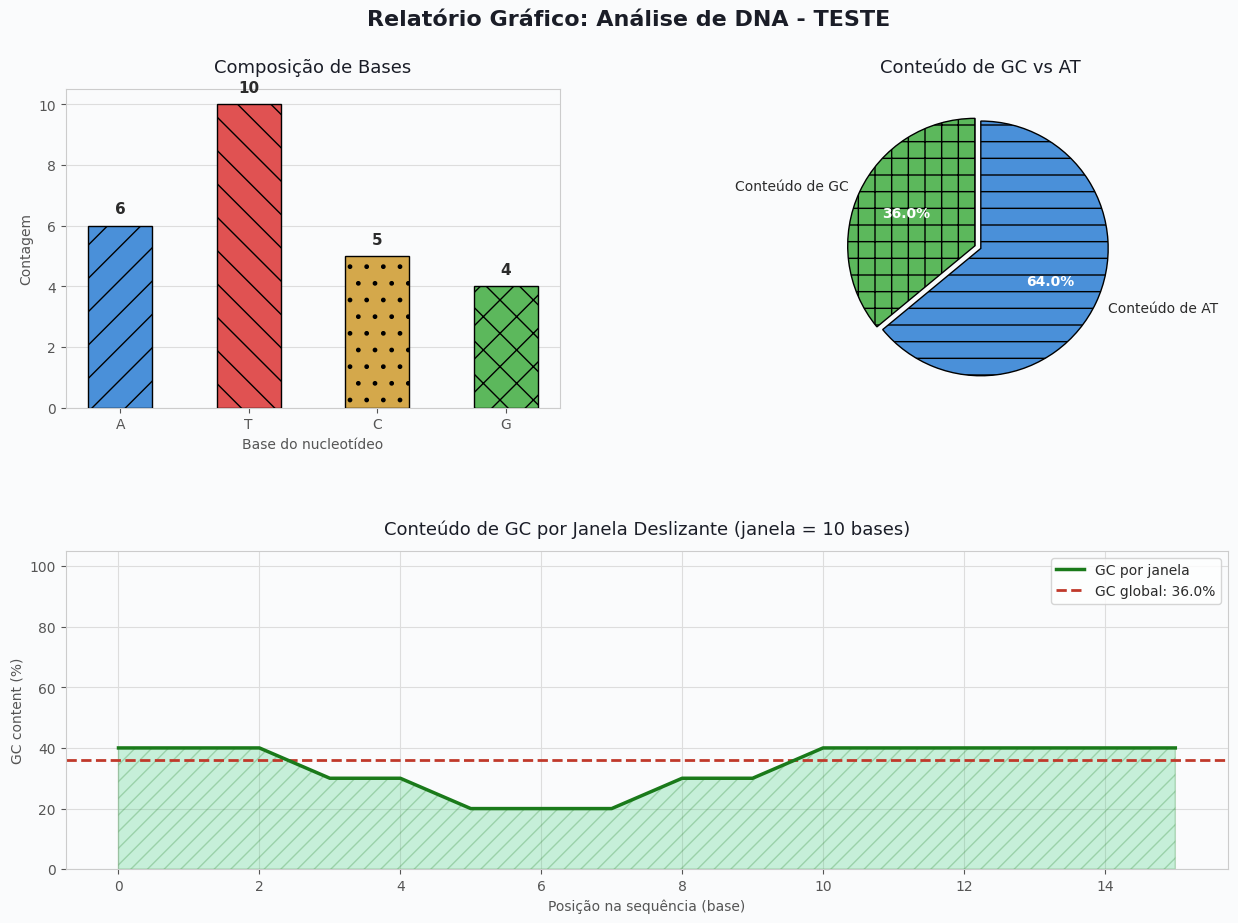

(<Figure size 1500x1000 with 3 Axes>, 'analise_dna.png')

In [21]:
#Relatório completo:
SEQUENCIA = SEQUENCIA

print("\n" + "--" * 50)
print("Análise de Bases em Sequências de DNA com Python para aplicações em Bioinformática - Relatório Final de Análise ")
print("--" * 50)

print(f"\nIndivíduo: {NOME_INDIVIDUO}")
print(f"Sequência analisada ({len(SEQUENCIA)} bases):\n")
print(f"  {SEQUENCIA}\n")

print(imprimir_relatorio(SEQUENCIA, nome_individuo=NOME_INDIVIDUO, motifs_extras=MOTIFS_EXTRAS))

#simulação de mutação
print("\n--- Simulação de Mutação (taxa: " + str(TAXA_MUTACAO) + ") " + "--" * 21 + "\n")
seq_mutada, mutacoes=simular_mutacao(SEQUENCIA, taxa_mutacao=TAXA_MUTACAO, semente=7)

print(f"Original: {SEQUENCIA}")
print(f"Mutada: {seq_mutada}")
print(f"\nTotal de mutações: {len(mutacoes)}")

for m in mutacoes:
    print(f" Posição{m['posicao']:3d}: {m['original']} = {m['mutada']}")

gc_original = calcular_gc(SEQUENCIA)
gc_mutada   = calcular_gc(seq_mutada)
print(f"\nGC original: {gc_original}%")
print(f"GC mutada: {gc_mutada}%")
print(f"Variação: {round(gc_mutada - gc_original, 2):+.2f}%\n")

#busca personalizada de motif:
motif_busca = MOTIFS_EXTRAS or []

if motif_busca:
	linhas = []
	print(f"--- Busca de '{motif_busca}'" + "--" * 30 + "\n")
	for motif in motif_busca:
		posicoes = buscar_motif(SEQUENCIA, motif)
		linha = (f"   '{motif}': encontrado {len(posicoes)} vez(es) --> posições {posicoes}")
		linhas.append(linha)
	print("\n".join(linhas))
	print()

salvar_relatorio(sequencia=SEQUENCIA, seq_mutada=seq_mutada, mutacoes=mutacoes, nome_individuo=NOME_INDIVIDUO, motifs_extras=motif_busca, taxa_mutacao=TAXA_MUTACAO, nome_arquivo=NOME_RELATORIO)

#graficos
print("\n--- Gerando painel de gráficos " + "--" * 27 + "\n")
gerar_graficos(SEQUENCIA, tamanho_janela=10, nome_individuo=NOME_INDIVIDUO, nome_arquivo=NOME_GRAFICO)

# Conclusão

Este projeto implementou, utilizando linguagem Python, um pipeline completo de análise de sequências de DNA — da validação dos dados brutos à geração de relatórios e visualizações gráficas.

As funcionalidades desenvolvidas cobrem etapas centrais da bioinformática computacional:

| Etapa | Função |
|-------|--------|
| Validação e limpeza | `validar_sequencia()` |
| Composição nucleotídica | `contar_bases()`, `calcular_gc()`, `calcular_at()` |
| Biologia estrutural | `complementar_reverso()` |
| Análise regional | `gc_por_janela()` |
| Anotação funcional | `buscar_motif()` |
| Variação genética | `simular_mutacao()` |
| Saída e visualização | `imprimir_relatorio()`, `gerar_graficos()`, `salvar_relatorio()` |

Cada função foi projetada de forma **modular e reutilizável**: recebe entradas validadas, executa uma única responsabilidade e retorna valores que alimentam as etapas seguintes. Esse princípio, inspirado na programação funcional, torna o código mais fácil de testar, corrigir e expandir.

Do ponto de vista biológico, as análises implementadas têm aplicações diretas: o conteúdo GC indica estabilidade térmica de regiões do genoma; a janela deslizante revela heterogeneidade regional que pode apontar para regiões codificantes ou regulatórias; a busca de motifs localiza sítios funcionais como o códon de início `ATG`; e a simulação de mutações ilustra como SNPs alteram a composição da sequência.

**Possíveis extensões futuras:**
- Tradução de sequências para proteínas (leitura de códons)
- Alinhamento entre duas sequências (algoritmo de Needleman-Wunsch)
- Leitura de arquivos no formato FASTA, padrão em bancos de dados genômicos como o NCBI
- Interface de linha de comando com `argparse` para uso sem Jupyter

O projeto demonstra que conceitos fundamentais de Python — strings, dicionários, listas, funções, módulos e visualização — são suficientes para construir ferramentas funcionais com aplicabilidade científica real.